# 🟡 Lesson 10 — Rioxarray

**Level: Intermediate** · Rasterio power with Xarray labels — reproject, clip and mask rasters in two lines.

*Part of the companion package for [python_for_geologists](https://github.com/kevinalexandr19/python_for_geologists) by Kevin Alexander Gomez.*

In [1]:
import rioxarray
import xarray as xr
from pathlib import Path
print("rioxarray", rioxarray.__version__)

GEN = Path("..") / "data" / "generated"
dem_path = GEN / "dem.tif"
assert dem_path.exists(), "Run lesson 09 first to create the DEM."

rioxarray 0.22.0


## 1. Open a GeoTIFF as a labelled array
Compare with plain rasterio: coordinates come attached automatically.

In [2]:
dem = rioxarray.open_rasterio(dem_path).squeeze("band", drop=True)
print(dem.dims, dem.shape)
print("CRS       :", dem.rio.crs)
print("resolution:", dem.rio.resolution())
dem

('y', 'x') (200, 200)
CRS       : EPSG:32718
resolution: (30.0, -30.0)


<xarray.DataArray (y: 200, x: 200)> Size: 160kB
[40000 values with dtype=float32]
Coordinates:
  * y            (y) float64 2kB 8.61e+06 8.61e+06 ... 8.604e+06 8.604e+06
  * x            (x) float64 2kB 4.8e+05 4.8e+05 4.801e+05 ... 4.86e+05 4.86e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

## 2. Select by real-world coordinate — no manual row/col math

In [3]:
val = dem.sel(x=482_000, y=8_606_500, method="nearest")
print("elevation at E482000/N8606500: %.0f m" % float(val))

elevation at E482000/N8606500: 3700 m


## 3. Clip to a bounding box

In [4]:
clip = dem.rio.clip_box(minx=481_000, miny=8_605_000, maxx=484_000, maxy=8_608_000)
print("clipped shape:", clip.shape)
print("clipped max  : %.0f m" % float(clip.max()))

clipped shape: (101, 101)


clipped max  : 3700 m


## 4. Reproject to geographic coordinates (WGS84)

In [5]:
dem_ll = dem.rio.reproject("EPSG:4326")
print("new CRS  :", dem_ll.rio.crs)
print("lon range: %.4f to %.4f" % (float(dem_ll.x.min()), float(dem_ll.x.max())))
print("lat range: %.4f to %.4f" % (float(dem_ll.y.min()), float(dem_ll.y.max())))

new CRS  : EPSG:4326
lon range: -75.1840 to -75.1290
lat range: -12.6278 to -12.5738


## 5. Raster math + save
Everything is still an Xarray object, so math is one-liners.

In [6]:
high = (dem > 3000).astype("uint8")          # binary map of terrain above 3000 m
high.rio.to_raster(GEN / "above_3000m.tif")
pct = float(high.mean()) * 100
print("area above 3000 m: %.1f%% of the scene -> saved above_3000m.tif" % pct)

area above 3000 m: 6.7% of the scene -> saved above_3000m.tif


## 6. Plot — Xarray plotting works out of the box

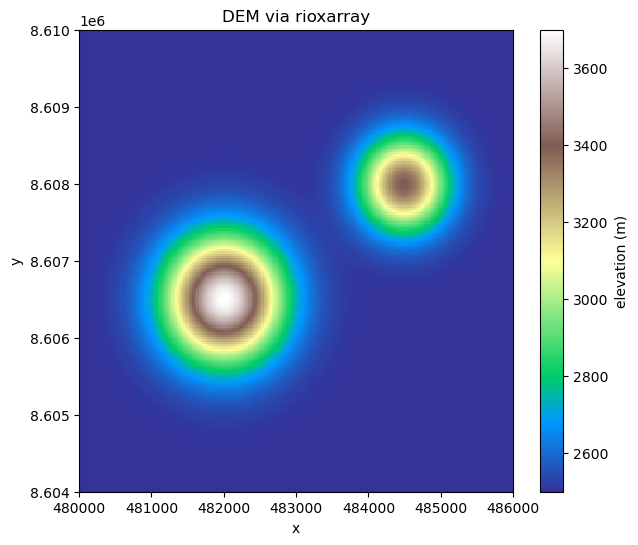

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 6))
dem.plot(ax=ax, cmap="terrain", cbar_kwargs={"label": "elevation (m)"})
ax.set_title("DEM via rioxarray")
plt.show()

### ✏️ Try it
1. Clip the DEM with the claim polygon from lesson 07 using `dem.rio.clip([geom], crs='EPSG:32718')`.
2. Reproject to EPSG:32719 (UTM 19S) and check how the resolution changes.

📚 Docs: https://corteva.github.io/rioxarray/stable/